# Variational autoencoders

### Learning a distribution instead of a point, so you can sample from it

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why a trained autoencoder cannot invent a new image even though it reconstructs beautifully, what changes when the encoder returns a mean and a log-variance instead of a single code, why sampling has to be rewritten as `mu + sigma * epsilon` before a gradient can pass through it, how the ELBO splits into a reconstruction term and a KL term that pulls every encoding toward the same standard normal, what the weight on that KL term buys and costs at both extremes, and how to sample and interpolate once the space has no holes in it |
| **You should already know** | [Autoencoders](../01-autoencoders/) · [The PyTorch training loop](../../07-neural-networks/03-the-same-net-in-pytorch/) |
| **Dataset** | Fashion-MNIST (28×28 greyscale, 10 classes; the same 12,000 training and 5,000 test images sampled in [10-01](../01-autoencoders/)) |
| **Runtime** | Five to seven minutes on a laptop CPU, about two on a GPU |
| **Next** | [10-03 Generative adversarial networks](../03-generative-adversarial-networks/) |

---

## 1. Why a plain autoencoder cannot generate

[10-01](../01-autoencoders/) left off with an autoencoder that rebuilds a garment
from sixteen numbers, and with a cheat sheet that named the obvious next wish
only to rule it out. The wish is this: if the decoder turns sixteen numbers into
a picture of clothing, then I should be able to make up sixteen numbers, hand
them over, and get a garment nobody has ever photographed.

It does not work, and the reason is worth being precise about, because the fix
in this notebook is aimed exactly at it.

Training an autoencoder puts no conditions on *where* the encoder places its
codes. The loss only cares that whatever code an image gets can be turned back
into that image. So the encoder is free to scatter the training set into
whatever arrangement is convenient: clumps of different densities, long thin
filaments, whole regions of code space that no image ever lands in. Those empty
regions are the problem. The decoder was never asked to produce anything
sensible there, no gradient ever touched it there, and its behaviour there is
unconstrained extrapolation.

```
  code space, plain autoencoder        code space, what sampling needs

    * **        ***                        ***********
  ****   ..        **                    ***************
     *      ..        ****              *****************
   **    ..  gap    *                    ***************
                                           ***********
  invent a code in the gap ->            invent a code anywhere ->
  the decoder has never been there       the decoder has been trained there
```

So the question this notebook answers is not "how do I make the decoder better".
The decoder is fine. The question is how to force the encoder to fill a known,
simple, hole-free region, so that inventing a code is safe.

I will start by showing the failure rather than asserting it. The comparison
against the fixed version arrives in section 5, once there is something to
compare against.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


In [2]:
train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]

N_TRAIN, N_TEST = 12_000, 5_000


def as_matrix(dataset, n_rows, seed=SEED):
    """Flatten a random subsample into one (rows, 784) tensor of floats in [0, 1].

    The same helper as 10-01, and the same subsample, so anything measured here
    can be put next to the numbers in that notebook. Eight small models get
    trained below; on all 60,000 images that would be an hour for a conclusion
    a fifth of the data already supports.
    """
    generator = torch.Generator().manual_seed(seed)
    picks = torch.randperm(len(dataset), generator=generator)[:n_rows].tolist()
    images = torch.stack([dataset[i][0] for i in picks]).view(len(picks), -1)
    labels = torch.tensor([dataset[i][1] for i in picks])
    return images, labels


X_train, y_train = as_matrix(train_set, N_TRAIN)
X_test, y_test = as_matrix(test_set, N_TEST)

print(f"training matrix {tuple(X_train.shape)}, test matrix {tuple(X_test.shape)}")
print(f"pixel range {X_train.min():.1f} to {X_train.max():.1f}")

training matrix (12000, 784), test matrix (5000, 784)
pixel range 0.0 to 1.0


One change from 10-01 before any model appears. That notebook trained on
squared error; here every model is trained on **binary cross-entropy summed
over the 784 pixels**, treating each pixel value as the mean of a Bernoulli.
There are two reasons. The variational objective in section 4 is a sum of
log-likelihoods and a KL divergence measured in nats, so the two terms have to
be in the same units before adding them is meaningful. And the plain
autoencoder here has to be trained on the identical reconstruction loss, or
every comparison in this notebook is comparing losses rather than models.

Both networks therefore end in a linear layer producing **logits**, and the
sigmoid lives inside the loss function or inside the display helper, never in
the model.

In [3]:
WIDTHS = (256, 128)
LATENT = 16          # the working size, used for sampling and interpolation
LATENT_VIS = 2       # the size you can plot, used for the latent-space figure
EPOCHS = 12


def decoder_stack(latent, n_out=784, widths=WIDTHS):
    """Mirror of the encoder, ending in logits rather than probabilities."""
    wide, narrow = widths
    return nn.Sequential(
        nn.Linear(latent, narrow), nn.ReLU(),
        nn.Linear(narrow, wide), nn.ReLU(),
        nn.Linear(wide, n_out),
    )


class PlainAutoencoder(nn.Module):
    """10-01's model, re-expressed in logits so the loss can be shared."""

    def __init__(self, latent, n_in=784, widths=WIDTHS):
        super().__init__()
        wide, narrow = widths
        self.encoder = nn.Sequential(
            nn.Linear(n_in, wide), nn.ReLU(),
            nn.Linear(wide, narrow), nn.ReLU(),
            nn.Linear(narrow, latent),      # one point per image, unbounded
        )
        self.decoder = decoder_stack(latent, n_in, widths)

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_plain(model, X, epochs=EPOCHS, lr=2e-3, batch_size=128):
    """Reconstruction only. Loss is nats per image, not per pixel."""
    model = model.to(device)
    X = X.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(X), device=device)
        running = 0.0
        for start in range(0, len(X), batch_size):
            batch = X[order[start:start + batch_size]]
            optimiser.zero_grad()
            loss = F.binary_cross_entropy_with_logits(
                model(batch), batch, reduction="sum") / len(batch)
            loss.backward()
            optimiser.step()
            running += loss.item() * len(batch)
        history.append(running / len(X))
    return model, history


@torch.no_grad()
def codes(model, X, batch_size=1000):
    """Every image's code, in one tensor on the CPU."""
    model.eval()
    return torch.cat([model.encode(X[i:i + batch_size].to(device)).cpu()
                      for i in range(0, len(X), batch_size)])


@torch.no_grad()
def decode(model, z, batch_size=1000):
    """Codes to pictures. The sigmoid that the model does not carry lives here."""
    model.eval()
    return torch.cat([torch.sigmoid(model.decoder(z[i:i + batch_size].to(device))).cpu()
                      for i in range(0, len(z), batch_size)])


started = time.perf_counter()
torch.manual_seed(SEED)
plain, plain_curve = train_plain(PlainAutoencoder(LATENT), X_train)
print(f"plain autoencoder, {LATENT}-number code, trained in "
      f"{time.perf_counter() - started:.0f} seconds on {device}")
print(f"reconstruction loss, nats per image: "
      f"first epoch {plain_curve[0]:.1f}, last epoch {plain_curve[-1]:.1f}")

plain autoencoder, 16-number code, trained in 4 seconds on cuda
reconstruction loss, nats per image: first epoch 335.4, last epoch 227.2


Now the experiment. I take the codes the encoder assigns to the training set,
measure their mean and standard deviation in each of the sixteen dimensions,
and draw new codes from a Gaussian with those same moments. This is the most
generous version of "invent a code" available without changing the model: the
invented codes sit in the middle of the occupied region and at the right scale.
If anything is going to work, this is it.

To score the result without squinting, I measure the Euclidean distance from
each decoded image to its nearest neighbour among the 12,000 training images.
Real held-out garments give the yardstick: that is how far a genuine, unseen
piece of clothing sits from the closest thing the model was trained on.

In [4]:
N_SAMPLES = 256


@torch.no_grad()
def nearest_real_distance(images, reference, chunk=64):
    """Distance from each image to the closest image in `reference`.

    Chunked because the full 256 x 12,000 distance matrix is cheap but the
    intermediate broadcast that a naive version builds is not.
    """
    reference = reference.to(device)
    out = []
    for i in range(0, len(images), chunk):
        d = torch.cdist(images[i:i + chunk].to(device), reference)
        out.append(d.min(dim=1).values.cpu())
    return torch.cat(out)


def spread(images):
    """Average per-pixel standard deviation across a batch.

    Near zero means every picture in the batch is the same picture, which is a
    failure mode section 4 runs into on purpose.
    """
    return images.std(dim=0).mean().item()


generator = torch.Generator().manual_seed(SEED)
Z_plain_train = codes(plain, X_train)

invented = (Z_plain_train.mean(0)
            + Z_plain_train.std(0) * torch.randn(N_SAMPLES, LATENT, generator=generator))
plain_samples = decode(plain, invented)

real_yardstick = nearest_real_distance(X_test[:N_SAMPLES], X_train)
plain_distance = nearest_real_distance(plain_samples, X_train)

print("distance to the nearest of the 12,000 training images (lower = more like real data):")
print(f"  real held-out garments        : {real_yardstick.mean():.3f}")
print(f"  plain autoencoder, made-up code: {plain_distance.mean():.3f}")
print()
print(f"pixel spread across the batch, real held-out : {spread(X_test[:N_SAMPLES]):.4f}")
print(f"pixel spread across the batch, made-up codes : {spread(plain_samples):.4f}")

distance to the nearest of the 12,000 training images (lower = more like real data):
  real held-out garments        : 3.980
  plain autoencoder, made-up code: 4.605

pixel spread across the batch, real held-out : 0.2739
pixel spread across the batch, made-up codes : 0.1929


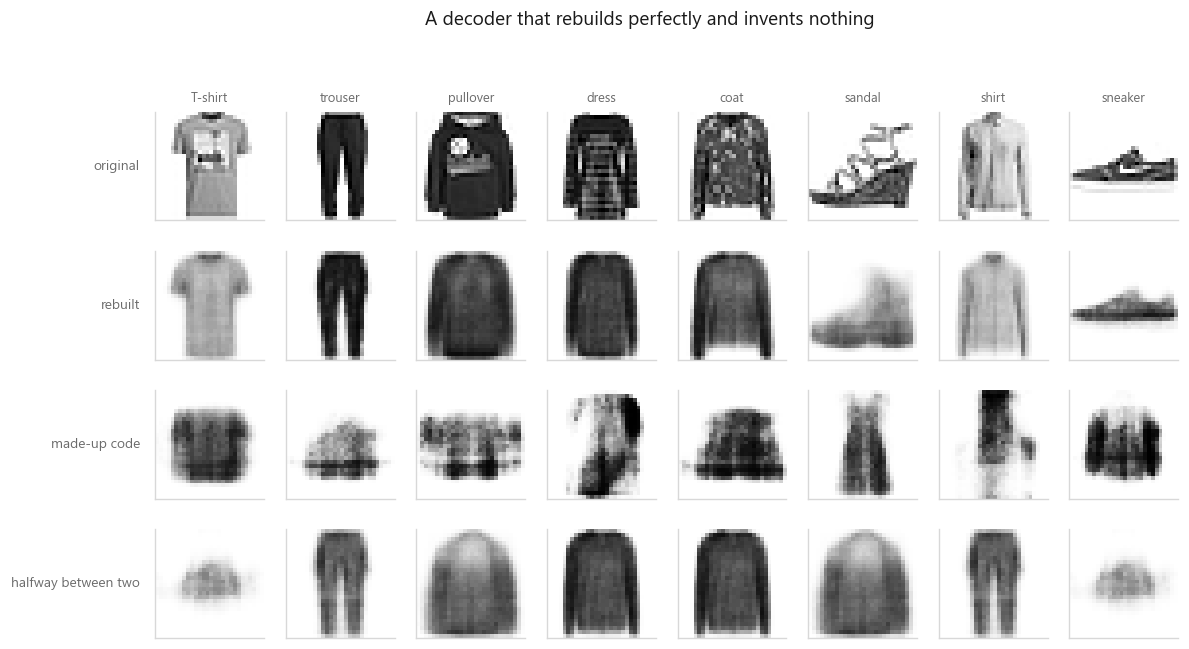

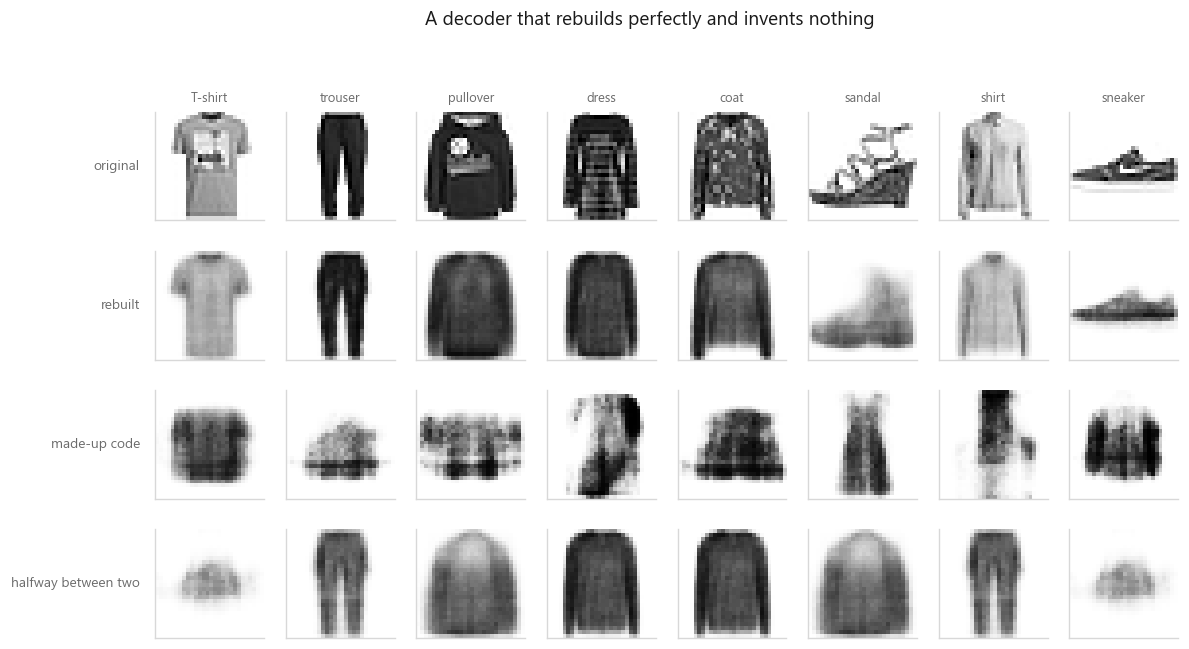

In [5]:
# Eight test garments, one per class, so the same items appear in every row.
picks = [int((y_test == c).nonzero(as_tuple=True)[0][0]) for c in range(8)]
originals = X_test[picks]
Z_plain_test = codes(plain, X_test)


def image_grid(rows, headline, path, column_titles=None, cell=1.5):
    """One labelled row per tensor of images. Used three times in this notebook."""
    n_rows, n_cols = len(rows), len(rows[0][1])
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(cell * n_cols, 1.05 * cell * n_rows))
    axes = np.atleast_2d(axes)
    for r, (label, batch) in enumerate(rows):
        for c in range(n_cols):
            ax = axes[r, c]
            ax.imshow(batch[c].view(28, 28), cmap="gray_r", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if c == 0:
                ax.set_ylabel(label, fontsize=9, color=style.MUTED,
                              rotation=0, ha="right", va="center", labelpad=10)
            if r == 0 and column_titles is not None:
                ax.set_title(column_titles[c], fontsize=8.5, color=style.MUTED)
    fig.suptitle(headline, x=0.5, y=1.02, fontsize=12.5, color=style.INK)
    style.save(fig, path)
    return fig


# Midpoints between pairs of real codes: the same eight images paired with
# themselves reversed, so each midpoint sits between two genuinely different
# garments.
midpoints = 0.5 * (Z_plain_test[picks] + Z_plain_test[picks[::-1]])

image_grid(
    [("original", originals),
     ("rebuilt", decode(plain, Z_plain_test[picks])),
     ("made-up code", plain_samples[:8]),
     ("halfway between two", decode(plain, midpoints))],
    "A decoder that rebuilds perfectly and invents nothing",
    FIG / "fig-01-plain-autoencoder-cannot-generate.png",
    column_titles=[CLASSES[int(y_test[p])] for p in picks],
)

The second row is the model doing its job. The third row is the same decoder,
fed codes drawn from a distribution fitted to its own codes, and the printed
distances say how far those pictures sit from anything real. The fourth row is
the more damning one, because a midpoint between two real codes is not even an
invented region: it is the straight line between two places the encoder
actually used. If the space were filled, a point on that line would decode to
something between the two garments.

Nothing about this is fixable by training longer. The encoder was never asked
to leave the space usable, so it did not.

## 2. A distribution instead of a point

The change is smaller than it sounds. Instead of the encoder returning a code,
it returns a **description of a cloud** of codes: a mean vector $\mu(x)$ and a
per-dimension variance $\sigma^2(x)$. The image is no longer at a point in code
space; it occupies a small Gaussian blob.

$$q_\phi(z \mid x) = \mathcal{N}\!\left(\mu_\phi(x),\ \operatorname{diag}\sigma^2_\phi(x)\right)$$

Training then works like this: encode an image to get its blob, **draw one
sample from that blob**, decode the sample, and score the reconstruction. Every
time the same image comes round it gets a slightly different code, so the
decoder is forced to produce that same image from a whole neighbourhood rather
than from one point. The blob is a region of code space that has been claimed
and made safe.

Two details in the implementation.

**The encoder returns log-variance, not variance.** A variance has to be
positive, and a linear layer's output is not. Squaring or exponentiating the
output afterwards would work, but predicting $\log \sigma^2$ directly is the
clean version: the layer is free to output any real number, $\sigma = \exp(\tfrac{1}{2}\log\sigma^2)$
is positive by construction, and the KL formula in section 4 wants
$\log \sigma^2$ anyway, so nothing has to be logged back.

**The two heads share a trunk.** The mean and the width of an image's blob are
both functions of the same image, and the features useful for one are useful
for the other. Only the final layer splits.

In [6]:
class VAE(nn.Module):
    """Encoder returns (mu, logvar); the decoder is unchanged from the plain model."""

    def __init__(self, latent, n_in=784, widths=WIDTHS):
        super().__init__()
        wide, narrow = widths
        self.trunk = nn.Sequential(
            nn.Linear(n_in, wide), nn.ReLU(),
            nn.Linear(wide, narrow), nn.ReLU(),
        )
        self.to_mu = nn.Linear(narrow, latent)
        self.to_logvar = nn.Linear(narrow, latent)
        self.decoder = decoder_stack(latent, n_in, widths)

    def encode(self, x):
        h = self.trunk(x)
        # The clamp only matters at beta = 0, where nothing pushes back on the
        # variance and logvar would otherwise drift far enough to make exp()
        # awkward. At any sensible beta it never binds.
        return self.to_mu(h), self.to_logvar(h).clamp(-10.0, 10.0)

    def reparameterise(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * torch.randn_like(sigma)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decoder(self.reparameterise(mu, logvar)), mu, logvar


count = lambda m: sum(p.numel() for p in m.parameters())
print(f"plain autoencoder, {LATENT}-number code : {count(PlainAutoencoder(LATENT)):,} parameters")
print(f"variational autoencoder, same code size : {count(VAE(LATENT)):,} parameters")

probe = VAE(LATENT)
mu_probe, logvar_probe = probe.encode(X_train[:4])
print(f"\nencoder output for a batch of 4: mu {tuple(mu_probe.shape)}, "
      f"logvar {tuple(logvar_probe.shape)}")
print("the decoder's input is one draw from that, so its shape is unchanged: "
      f"{tuple(probe.reparameterise(mu_probe, logvar_probe).shape)}")

plain autoencoder, 16-number code : 472,608 parameters
variational autoencoder, same code size : 474,672 parameters

encoder output for a batch of 4: mu (4, 16), logvar (4, 16)
the decoder's input is one draw from that, so its shape is unchanged: (4, 16)


## 3. The reparameterisation trick

There is a problem sitting in the middle of that forward pass, and it is not
obvious until you try to differentiate it.

Backpropagation needs a chain of differentiable operations from the loss back
to every parameter. The chain here runs: loss, decoder, sampled code $z$,
encoder, parameters. But "sample from $\mathcal{N}(\mu, \sigma^2)$" is not a
differentiable operation on $\mu$ and $\sigma$. It is a call to a random number
generator. Ask autograd for $\partial z / \partial \mu$ and there is nothing to
return, because $z$ came out of a sampler, not out of an arithmetic expression
involving $\mu$. The gradient stops dead at the sampling step, the encoder
never receives one, and it never learns.

The trick is to move the randomness out of the path. Instead of sampling from a
distribution whose parameters we want gradients for, sample from a fixed one
and reshape the draw:

$$\varepsilon \sim \mathcal{N}(0, I), \qquad z = \mu + \sigma \odot \varepsilon$$

The two are the same distribution. But now $\varepsilon$ is an *input* (a
constant, as far as autograd is concerned, drawn before the arithmetic starts),
and $z$ is an ordinary differentiable function of $\mu$ and $\sigma$, with
$\partial z/\partial \mu = 1$ and $\partial z/\partial \sigma = \varepsilon$.
The randomness is still there. It is just no longer on the path the gradient
has to travel.

PyTorch names the distinction directly: `.sample()` draws and detaches,
`.rsample()` draws by reparameterising.

In [7]:
mu = torch.tensor(1.0, requires_grad=True)
sigma = torch.tensor(1.0)
q = torch.distributions.Normal(mu, sigma)

print(f"sample()  produces a tensor connected to mu : {q.sample().requires_grad}")
print(f"rsample() produces a tensor connected to mu : {q.rsample().requires_grad}")

# The hand-written version is exactly what rsample does.
eps_check = torch.randn(5)
z_check = mu + sigma * eps_check
autograd_grad = torch.autograd.grad((z_check ** 2).sum(), mu)[0]
print(f"\nd/dmu of sum(z^2) over 5 draws, from autograd : {autograd_grad.item():.4f}")
print(f"the same thing worked out by hand, sum(2z)    : {(2 * z_check).sum().item():.4f}")

sample()  produces a tensor connected to mu : False
rsample() produces a tensor connected to mu : True

d/dmu of sum(z^2) over 5 draws, from autograd : 17.6480
the same thing worked out by hand, sum(2z)    : 17.6480


"You cannot backpropagate through a sampler" is true but slightly too strong,
and the fuller answer is the better reason to use reparameterisation. There
*is* another way to get an unbiased gradient through a sampling step, the
score-function estimator that reinforcement learning uses:

$$\nabla_\mu \mathbb{E}_{q}\!\left[f(z)\right] = \mathbb{E}_{q}\!\left[f(z)\,\nabla_\mu \log q(z)\right]$$

It needs no derivative of $f$ at all, which is why it works on discrete choices
and non-differentiable rewards. The catch is its variance. Below I estimate
$\frac{d}{d\mu}\mathbb{E}[z^2]$ for $z \sim \mathcal{N}(\mu, 1)$, where the
answer is exactly $2\mu$, using both estimators on the same draws.

In [8]:
N_DRAWS = 20_000
torch.manual_seed(SEED)

with torch.no_grad():
    eps = torch.randn(N_DRAWS)
    z = mu + sigma * eps
    pathwise = 2 * z                                  # d/dmu of f(z) through z = mu + sigma*eps
    score = (z ** 2) * (z - mu) / sigma ** 2          # f(z) * dlog q / dmu

print(f"true gradient                         : {2 * mu.item():.4f}")
print(f"reparameterised, mean over {N_DRAWS:,} draws : {pathwise.mean():.4f}"
      f"   (std of one draw {pathwise.std():.3f})")
print(f"score function,  mean over {N_DRAWS:,} draws : {score.mean():.4f}"
      f"   (std of one draw {score.std():.3f})")
print(f"\ndraws the score function needs to match the reparameterised estimator's "
      f"standard error: {(score.std() / pathwise.std()) ** 2:.1f}x as many")

true gradient                         : 2.0000
reparameterised, mean over 20,000 draws : 1.9761   (std of one draw 2.009)
score function,  mean over 20,000 draws : 1.9895   (std of one draw 5.612)

draws the score function needs to match the reparameterised estimator's standard error: 7.8x as many


Both estimators are unbiased and both means land near the truth. The spread is
the difference, and it decides whether training is possible with the batch
sizes anyone actually uses. The reparameterised estimator gets to differentiate
$f$ itself, so it knows which direction to move; the score-function estimator
only sees the value of $f$ and has to infer the direction from correlation.
When the decoder is differentiable there is no reason to give up that
information.

## 4. The ELBO and the beta tradeoff, measured

Now the loss. What I would like to maximise is the log-likelihood the model
assigns to real data, $\log p_\theta(x)$. That involves an integral over every
possible code, which is not available. The standard move is to introduce the
encoder $q_\phi(z \mid x)$ as an approximation to the true posterior and rewrite:

$$\log p_\theta(x) \;=\; \underbrace{\mathbb{E}_{q_\phi(z \mid x)}\!\left[\log p_\theta(x \mid z)\right] - D_{\mathrm{KL}}\!\left(q_\phi(z \mid x)\,\|\,p(z)\right)}_{\text{ELBO}} \;+\; D_{\mathrm{KL}}\!\left(q_\phi(z \mid x)\,\|\,p_\theta(z \mid x)\right)$$

The last term cannot be computed, but a KL divergence is never negative, so
dropping it can only make the expression smaller. What remains is a lower bound
on the log-likelihood, the **evidence lower bound**. Push it up and you push up
on $\log p_\theta(x)$ from below, while squeezing the encoder toward the true
posterior. Two useful things from one objective.

In code the ELBO has two terms, and I minimise their negative.

**The reconstruction term** is the cross-entropy between the decoder's output
and the input, exactly as before, except the code fed to the decoder is a draw
rather than a point.

**The KL term** has a closed form when both distributions are diagonal
Gaussians and the prior is standard normal:

$$D_{\mathrm{KL}}\!\left(\mathcal{N}(\mu, \operatorname{diag}\sigma^2) \,\|\, \mathcal{N}(0, I)\right) = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

Read it as two springs. The $\mu_j^2$ term pulls every mean toward the origin.
The $\sigma_j^2$ and $\log \sigma_j^2$ terms together are minimised at
$\sigma_j = 1$, so they pull every blob toward unit width, punishing widths that
shrink toward zero as hard as widths that grow. The result is that all the
blobs get dragged onto the same patch of code space and inflated until they
overlap. Overlapping blobs are what fills the holes, because the decoder is
trained on samples from every blob, and between any two nearby images there is
now code space that both of them claim.

In [9]:
def vae_terms(logits, x, mu, logvar):
    """Reconstruction and KL, both in nats per image."""
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="sum") / len(x)
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum() / len(x)
    return recon, kl


def train_vae(model, X, beta=1.0, epochs=EPOCHS, lr=2e-3, batch_size=128):
    model = model.to(device)
    X = X.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(X), device=device)
        running_recon = running_kl = 0.0
        for start in range(0, len(X), batch_size):
            batch = X[order[start:start + batch_size]]
            optimiser.zero_grad()
            logits, mu, logvar = model(batch)
            recon, kl = vae_terms(logits, batch, mu, logvar)
            (recon + beta * kl).backward()
            optimiser.step()
            running_recon += recon.item() * len(batch)
            running_kl += kl.item() * len(batch)
        history.append((running_recon / len(X), running_kl / len(X)))
    return model, history


@torch.no_grad()
def evaluate_vae(model, X, batch_size=1000):
    """Held-out reconstruction and KL. Reconstruction is stochastic by design,
    since the ELBO's first term is an expectation over the encoder's own noise."""
    model.eval()
    recon_total = kl_total = 0.0
    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size].to(device)
        logits, mu, logvar = model(xb)
        recon, kl = vae_terms(logits, xb, mu, logvar)
        recon_total += recon.item() * len(xb)
        kl_total += kl.item() * len(xb)
    return recon_total / len(X), kl_total / len(X)


@torch.no_grad()
def posterior(model, X, batch_size=1000):
    """Every image's mu and logvar."""
    model.eval()
    mus, logvars = [], []
    for i in range(0, len(X), batch_size):
        mu_b, logvar_b = model.encode(X[i:i + batch_size].to(device))
        mus.append(mu_b.cpu()); logvars.append(logvar_b.cpu())
    return torch.cat(mus), torch.cat(logvars)


@torch.no_grad()
def reconstruct_vae(model, X):
    """Reconstruction from the mean of the blob, with the noise switched off."""
    model.eval()
    mu, _ = posterior(model, X)
    return decode(model, mu)


def sample_prior(model, latent, n, seed=SEED):
    """The point of the whole exercise: codes from N(0, I), never from data."""
    g = torch.Generator().manual_seed(seed)
    return decode(model, torch.randn(n, latent, generator=g))

### What the constraint does to the picture

Two numbers is a hopeless code for reconstruction and the only size you can
look at directly, so I train one plain autoencoder and one variational
autoencoder at that size and plot where each puts the test set. The crosses are
codes I invented: for the plain model, drawn from a Gaussian fitted to its own
codes, and for the variational model, drawn from the standard normal it was
trained against. Where a cross lands relative to the dots is the whole argument
of this notebook.

In [10]:
started = time.perf_counter()
torch.manual_seed(SEED)
plain_2d, _ = train_plain(PlainAutoencoder(LATENT_VIS), X_train)
torch.manual_seed(SEED)
vae_2d, _ = train_vae(VAE(LATENT_VIS), X_train, beta=1.0)
print(f"two 2-D models in {time.perf_counter() - started:.0f} seconds")

Z_plain_2d = codes(plain_2d, X_test).numpy()
mu_2d, logvar_2d = posterior(vae_2d, X_test)
Z_vae_2d = mu_2d.numpy()

g = torch.Generator().manual_seed(SEED + 1)
plain_2d_train = codes(plain_2d, X_train)
crosses_plain = (plain_2d_train.mean(0)
                 + plain_2d_train.std(0) * torch.randn(40, LATENT_VIS, generator=g)).numpy()
crosses_vae = torch.randn(40, LATENT_VIS, generator=g).numpy()

two 2-D models in 10 seconds


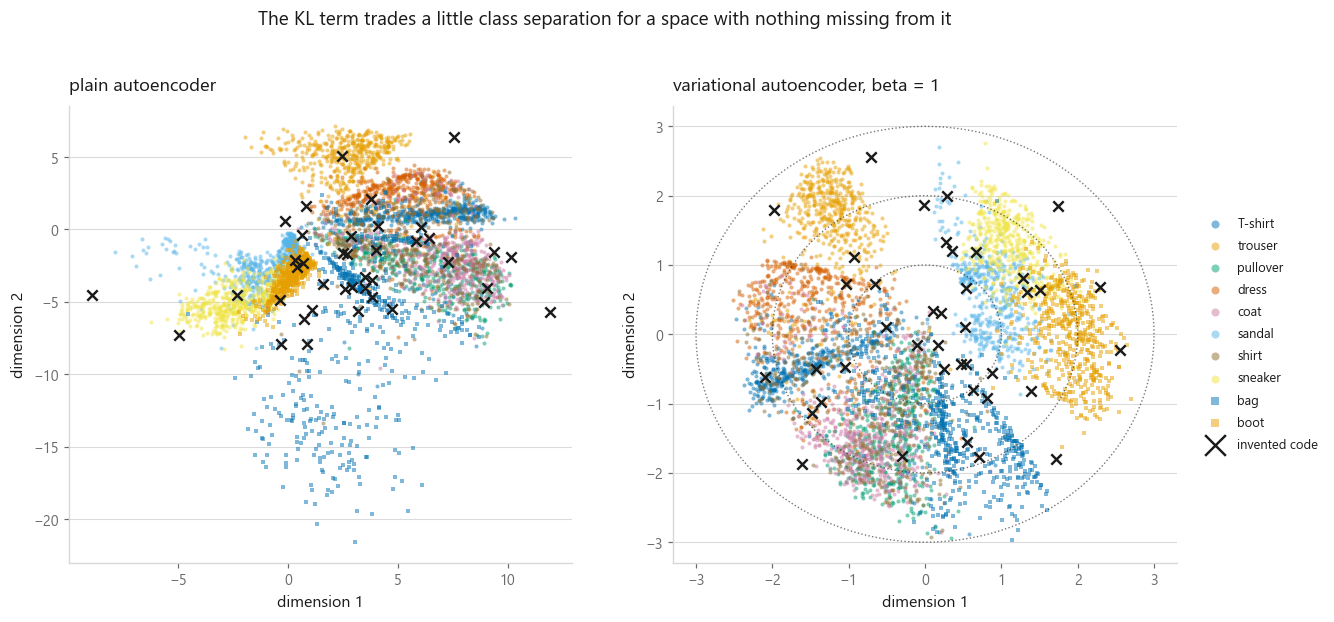

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))
panels = [(axes[0], "plain autoencoder", Z_plain_2d, crosses_plain, False),
          (axes[1], "variational autoencoder, beta = 1", Z_vae_2d, crosses_vae, True)]

for ax, name, coords, crosses, draw_prior in panels:
    for c in range(10):
        mask = (y_test == c).numpy()
        # Ten classes into an eight-colour palette, so the last two are separated
        # by marker shape. Colour is never the only channel here.
        ax.scatter(coords[mask, 0], coords[mask, 1], s=7, alpha=0.5, linewidths=0,
                   color=style.PALETTE[c % 8], marker=style.MARKERS[c // 8],
                   label=CLASSES[c])
    if draw_prior:
        angles = np.linspace(0, 2 * np.pi, 200)
        for radius in (1, 2, 3):
            ax.plot(radius * np.cos(angles), radius * np.sin(angles),
                    color=style.INK, linewidth=0.9, linestyle=":", alpha=0.6)
    ax.scatter(crosses[:, 0], crosses[:, 1], marker="x", s=46, linewidths=1.6,
               color=style.INK, label="invented code", zorder=5)
    ax.set_xlabel("dimension 1"); ax.set_ylabel("dimension 2")
    style.title(ax, name)

axes[1].legend(loc="center left", bbox_to_anchor=(1.03, 0.5), fontsize=8.5,
               markerscale=2.0, labelspacing=0.7)
fig.suptitle("The KL term trades a little class separation for a space with "
             "nothing missing from it",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-latent-space.png")

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = lambda Z_tr, Z_te: KNeighborsClassifier(15).fit(
    Z_tr, y_train.numpy()).score(Z_te, y_test.numpy())

print("15-nearest-neighbour accuracy on two coordinates (how much class signal survives):")
print(f"  plain autoencoder        : "
      f"{knn(plain_2d_train.numpy(), Z_plain_2d):.4f}")
print(f"  variational autoencoder  : "
      f"{knn(posterior(vae_2d, X_train)[0].numpy(), Z_vae_2d):.4f}")
print(f"  guessing                 : {1 / 10:.4f}")
print()
print("how far the code cloud sits from the standard normal it is supposed to match:")
for name, Z in [("plain autoencoder", Z_plain_2d), ("variational autoencoder", Z_vae_2d)]:
    print(f"  {name:<24}: mean {Z.mean():+.3f}, std {Z.std():.3f}  (target 0.000, 1.000)")

15-nearest-neighbour accuracy on two coordinates (how much class signal survives):
  plain autoencoder        : 0.6804
  variational autoencoder  : 0.6768
  guessing                 : 0.1000

how far the code cloud sits from the standard normal it is supposed to match:
  plain autoencoder       : mean +0.823, std 4.523  (target 0.000, 1.000)
  variational autoencoder : mean -0.181, std 1.221  (target 0.000, 1.000)


The variational panel is bounded, roughly centred, roughly unit width, and its
classes touch each other instead of sitting in separate islands with space
between them. That contact is not a defect. It is what "no holes" looks like:
the boundary between two classes has to be somewhere, and in a space you intend
to sample from, the boundary needs to be a place where the decoder still draws
clothing.

The nearest-neighbour numbers are the price. Compare them to the plain model's
and to [10-01](../01-autoencoders/)'s, and the direction tells you what the KL
term costs in raw class separation at two dimensions.

### Turning the dial

The two terms disagree, and that is the whole story of this section.
Reconstruction wants every image far away from every other image, in its own
tiny well-separated blob, so there is no confusion about which image a code
belongs to. The KL wants every image piled at the origin with unit width, which
makes them indistinguishable. So I put a weight on the argument:

$$\mathcal{L}(\theta, \phi) = \underbrace{-\mathbb{E}_{q}\!\left[\log p_\theta(x \mid z)\right]}_{\text{reconstruction}} \;+\; \beta \underbrace{D_{\mathrm{KL}}\!\left(q_\phi(z \mid x)\,\|\,p(z)\right)}_{\text{KL}}$$

$\beta = 1$ is the actual ELBO. The other values are not, and I am sweeping them
because the two ends of the sweep are the two failure modes worth recognising.
At $\beta = 0$ the KL disappears and I am back to the model from section 1, with
noise that the network is free to shrink away. At large $\beta$ the cheapest
solution is to satisfy the KL exactly (every $\mu$ at zero, every $\sigma$ at
one), which means the code carries nothing about the image and the decoder has
no choice but to draw the average garment every time. That is **posterior
collapse**, and it is easy to spot once you know to look for identical outputs.

Five models at the working code size of sixteen, everything else held fixed.

In [13]:
BETAS = [0.0, 0.5, 1.0, 4.0, 16.0]

started = time.perf_counter()
vaes, sweep_rows = {}, []
for beta in BETAS:
    torch.manual_seed(SEED)
    vaes[beta], _ = train_vae(VAE(LATENT), X_train, beta=beta)

    recon, kl = evaluate_vae(vaes[beta], X_test)
    mu_test, logvar_test = posterior(vaes[beta], X_test)
    samples = sample_prior(vaes[beta], LATENT, N_SAMPLES)

    sweep_rows.append({
        "beta": beta,
        "recon": recon,
        "KL": kl,
        "mean sigma": torch.exp(0.5 * logvar_test).mean().item(),
        # A latent dimension counts as active if the mean it assigns actually
        # moves from image to image. The 0.01 threshold is the usual convention.
        "active dims": int((mu_test.var(dim=0) > 0.01).sum()),
        "recon spread": spread(reconstruct_vae(vaes[beta], X_test[:N_SAMPLES])),
        "sample->real": nearest_real_distance(samples, X_train).mean().item(),
        "sample spread": spread(samples),
    })

sweep = pd.DataFrame(sweep_rows)
print(sweep.round(3).to_string(index=False))
print(f"\nfive variational autoencoders in {time.perf_counter() - started:.0f} seconds "
      f"on {device}")
print(f"for reference, real held-out images   : sample->real "
      f"{real_yardstick.mean():.3f}, spread {spread(X_test[:N_SAMPLES]):.4f}")
print(f"the plain autoencoder from section 1  : sample->real "
      f"{plain_distance.mean():.3f}, spread {spread(plain_samples):.4f}")

 beta   recon      KL  mean sigma  active dims  recon spread  sample->real  sample spread
  0.0 229.453 165.294       0.008           16         0.249         2.506          0.044
  0.5 236.219  15.944       0.561           12         0.241         3.500          0.176
  1.0 240.608  10.403       0.709           12         0.240         3.192          0.199
  4.0 254.730   5.457       0.831            4         0.227         3.123          0.209
 16.0 287.705   2.380       0.909            2         0.200         3.113          0.188

five variational autoencoders in 33 seconds on cuda
for reference, real held-out images   : sample->real 3.980, spread 0.2739
the plain autoencoder from section 1  : sample->real 4.605, spread 0.1929


I said the two ends of the sweep were the two failure modes. One end delivered
and the other did not, so take them in that order.

**The collapsed end did not collapse.** I named reconstruction spread as the
check that settles it, a number near zero meaning the same garment every time.
At $\beta = 16$ it reads 0.200, against 0.249 at $\beta = 0$, so the outputs
still move with the input. Active dimensions fell to 2, not to 0. The KL fell to
2.380, not to nearly nothing. The model at $\beta = 16$ is squeezed into two
numbers per image and it is still using them. Posterior collapse is what this
end of the dial heads towards, and 16 was not far enough to arrive. If I want to
show the failure itself, the sweep has to go further or the decoder has to be
stronger.

**The point-like end behaved as advertised, and the metric I reached for
betrayed me.** At $\beta = 0$ the mean sigma is 0.008, so the blobs have
collapsed back to points and the means went wherever reconstruction wanted, which
is the plain autoencoder with extra steps. But the sample-to-real distance, which
I introduced as "lower is more like real data" and pointed at as the evidence,
comes out at 2.506 for that model. Real held-out garments score 3.980. On the
stated reading the broken model wins, and by a wide margin.

The sample spread column is what resolves it: 0.044 at $\beta = 0$ against
0.2739 for real images. A model drawing nearly the same picture every time draws
something close to the average garment, and the average garment is close to
everything, so its distance to the nearest real image is small for a reason that
has nothing to do with quality. Nearest-neighbour distance is a blur score as
much as a fidelity score, and it only means what I wanted it to mean when it is
read alongside a spread. That is why both columns are in the table.

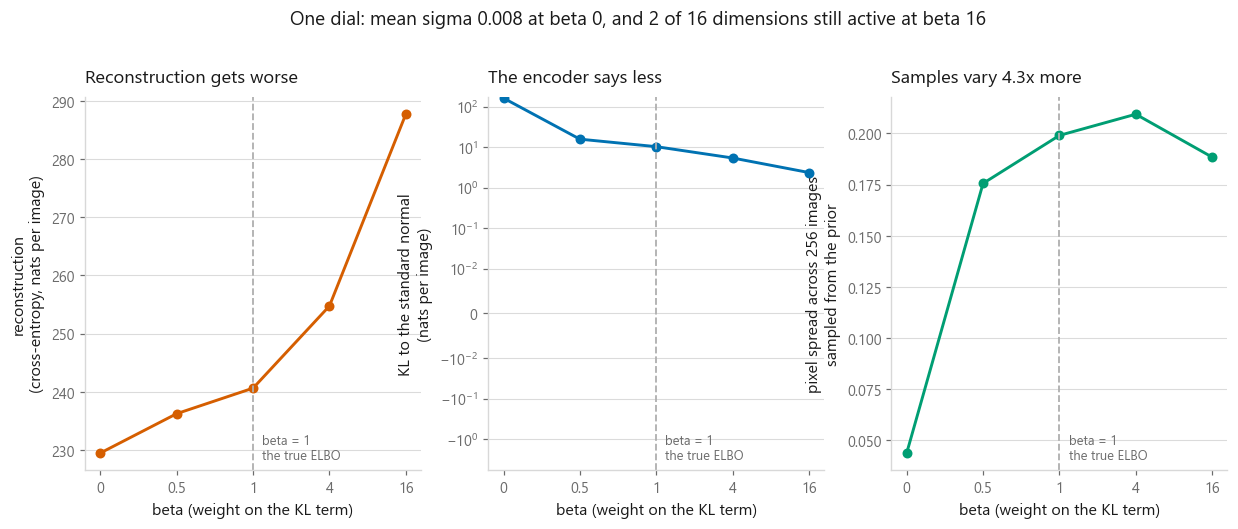

In [14]:
positions = np.arange(len(BETAS))
beta_labels = [("0" if b == 0 else f"{b:g}") for b in BETAS]

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.4))

# Each headline is read off the column it sits above, so none of them can end up
# describing a curve that went the other way.
def direction(column, up, down):
    return up if sweep[column].iloc[-1] > sweep[column].iloc[0] else down


spread_ratio = sweep["sample spread"].iloc[-1] / sweep["sample spread"].iloc[0]
sample_headline = (f"Samples vary {spread_ratio:.1f}x more"
                   if spread_ratio >= 1 else f"Samples vary {1 / spread_ratio:.1f}x less")

panels = [
    ("recon", "reconstruction\n(cross-entropy, nats per image)",
     direction("recon", "Reconstruction gets worse", "Reconstruction gets better"),
     style.HIGHLIGHT, False),
    ("KL", "KL to the standard normal\n(nats per image)",
     direction("KL", "The encoder says more", "The encoder says less"),
     style.PALETTE[0], True),
    ("sample spread", "pixel spread across 256 images\nsampled from the prior",
     sample_headline, style.PALETTE[2], False),
]
for ax, (column, ylabel, headline, colour, log_y) in zip(axes, panels):
    ax.plot(positions, sweep[column], marker=style.MARKERS[0], color=colour)
    ax.axvline(BETAS.index(1.0), color=style.NEUTRAL, linestyle="--", linewidth=1.2)
    ax.annotate("beta = 1\nthe true ELBO", xy=(BETAS.index(1.0), 0.03),
                xycoords=("data", "axes fraction"), xytext=(6, 0),
                textcoords="offset points", fontsize=8.5, color=style.MUTED)
    ax.set_xticks(positions, beta_labels)
    ax.set_xlabel("beta (weight on the KL term)")
    ax.set_ylabel(ylabel)
    if log_y:
        # symlog rather than log: the KL at the collapsed end can land close
        # enough to zero that a log axis would simply drop the point.
        ax.set_yscale("symlog", linthresh=0.01)
    style.title(ax, headline)

fig.suptitle(f"One dial: mean sigma {sweep['mean sigma'].iloc[0]:.3f} at beta "
             f"{beta_labels[0]}, and {sweep['active dims'].iloc[-1]} of {LATENT} "
             f"dimensions still active at beta {beta_labels[-1]}",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-beta-sweep.png")

## 5. Sampling and interpolating

Everything above was setup for two things a plain autoencoder cannot do.

The first is sampling. Draw $z \sim \mathcal{N}(0, I)$, decode, and look. There
is no image involved anywhere in that sentence: no encoder call, no data. The
reason it can work is that training spent every gradient step decoding samples
from blobs that the KL term had already dragged onto the standard normal, so
the region I am now drawing from is the region the decoder was trained on.

Below, both models are given exactly the same treatment: draw codes from the
distribution each one's training actually produced, decode, and print the same
two measurements as before.

In [15]:
vae = vaes[1.0]                       # the beta = 1 model from the sweep
vae_samples = sample_prior(vae, LATENT, N_SAMPLES, seed=SEED + 2)

g = torch.Generator().manual_seed(SEED + 2)
plain_samples_b = decode(plain, Z_plain_train.mean(0)
                         + Z_plain_train.std(0) * torch.randn(N_SAMPLES, LATENT, generator=g))

print("images produced from codes that no image ever occupied:")
print(f"{'':<26}{'dist. to nearest real':>22}{'pixel spread':>15}")
for name, batch in [("real held-out garments", X_test[:N_SAMPLES]),
                    ("plain autoencoder", plain_samples_b),
                    ("variational autoencoder", vae_samples)]:
    print(f"{name:<26}{nearest_real_distance(batch, X_train).mean():>22.3f}"
          f"{spread(batch):>15.4f}")

images produced from codes that no image ever occupied:
                           dist. to nearest real   pixel spread
real held-out garments                     3.980         0.2739
plain autoencoder                          4.572         0.1871
variational autoencoder                    3.282         0.2032


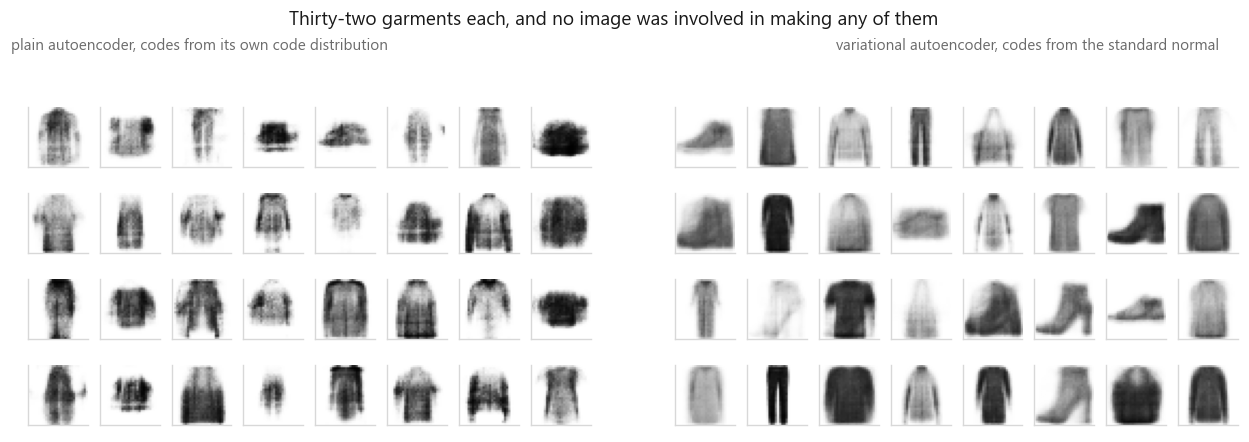

In [16]:
n_cols, n_rows_grid = 8, 4
fig, axes = plt.subplots(n_rows_grid, 2 * n_cols + 1, figsize=(14.2, 3.9))
for r in range(n_rows_grid):
    for c in range(2 * n_cols + 1):
        ax = axes[r, c]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if c == n_cols:
            ax.axis("off")                      # spacer between the two blocks
            continue
        batch, offset = ((plain_samples_b, 0) if c < n_cols
                         else (vae_samples, n_cols + 1))
        ax.imshow(batch[r * n_cols + (c - offset)].view(28, 28),
                  cmap="gray_r", vmin=0, vmax=1)

fig.text(0.235, 1.0, "plain autoencoder, codes from its own code distribution",
         ha="center", fontsize=10, color=style.MUTED)
fig.text(0.765, 1.0, "variational autoencoder, codes from the standard normal",
         ha="center", fontsize=10, color=style.MUTED)
fig.suptitle("Thirty-two garments each, and no image was involved in making any of them",
             x=0.5, y=1.09, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-prior-samples.png")

The same warning from the sweep applies to the numbers under those two grids.
The variational autoencoder's prior samples sit 3.282 from the nearest training
image while real held-out garments sit 3.980, so on distance alone the invented
clothes look more like the training set than genuine unseen clothes do. That is
a blurred average scoring well on a nearest-neighbour distance, not a model
producing better garments than reality. The spread column is what keeps it
honest: 0.2032 for the variational samples, 0.2739 for real images, 0.1871 for
the plain autoencoder's. Read as a pair the two columns say the variational
samples vary more than the plain autoencoder's and still less than real data,
which is what the two grids look like.

The second thing is interpolation. Encode two real images, walk along the
straight line between their codes, and decode every step. In a space with holes
the walk leaves the data almost immediately and comes back at the other end,
which shows up as one large jump somewhere in the middle. In a filled space
every intermediate code is a code the decoder knows, so the garment should
change gradually.

I can measure that rather than judge it by eye. Along each path I take the
pixel distance between consecutive frames. A smooth walk spends the same amount
of change on every step, so its largest step is close to its average one. A
walk that crosses a hole spends most of its change in one frame, and the ratio
of largest step to average step goes up.

evenness of the walk (1.0 would be a perfectly even path):
           path    model  mean step  largest step  largest / mean
boot to T-shirt plain AE      1.246         1.627           1.305
boot to T-shirt      VAE      1.056         1.367           1.294
 trouser to bag plain AE      1.609         2.292           1.424
 trouser to bag      VAE      1.655         2.101           1.270


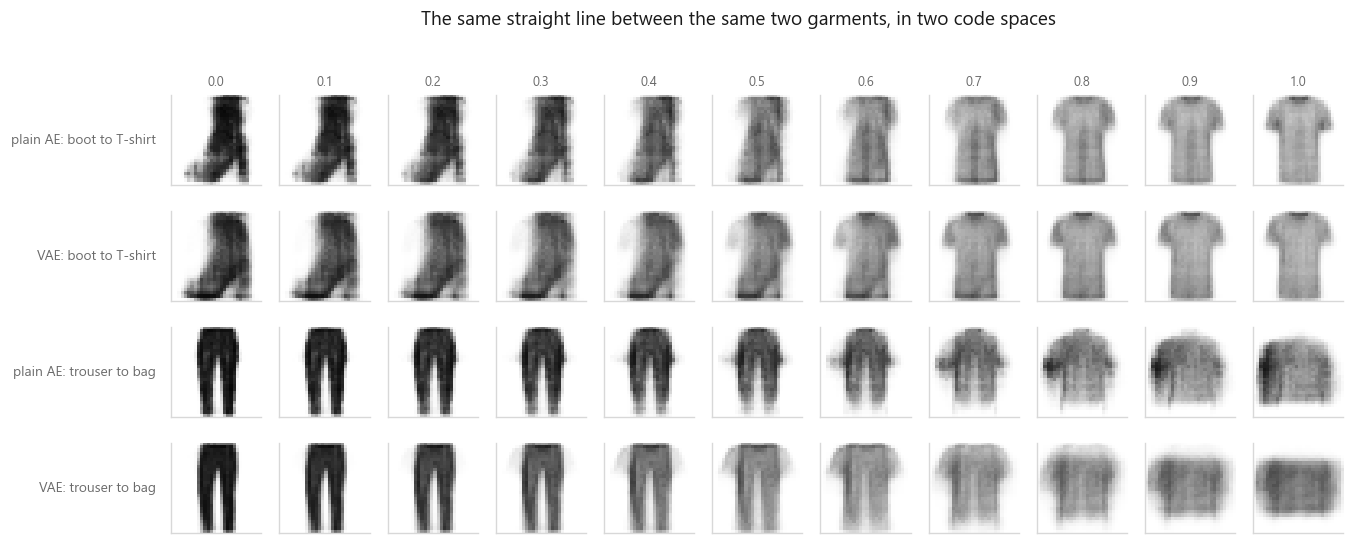

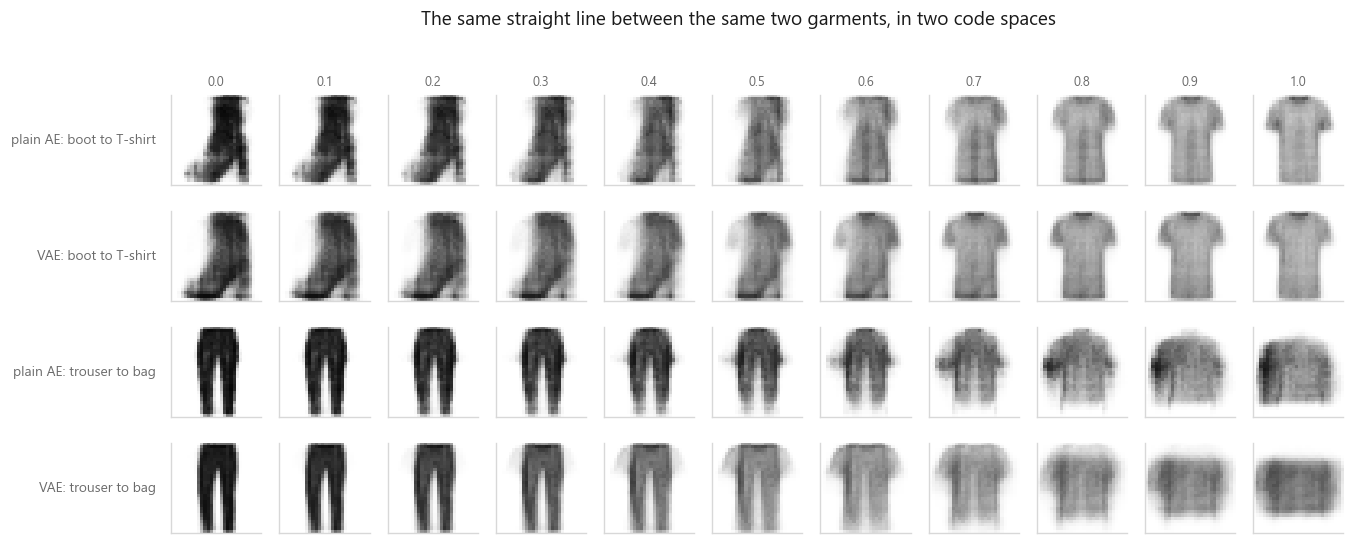

In [17]:
STEPS = 11
alphas = torch.linspace(0, 1, STEPS).unsqueeze(1)
pairs = [(9, 0), (1, 8)]              # boot to T-shirt, trouser to bag

mu_test_16, _ = posterior(vae, X_test)


def walk(z_start, z_end):
    return (1 - alphas) * z_start + alphas * z_end


def step_sizes(frames):
    """Pixel distance between consecutive frames along a path."""
    return (frames[1:] - frames[:-1]).pow(2).sum(dim=1).sqrt()


rows, report = [], []
for a, b in pairs:
    i = int((y_test == a).nonzero(as_tuple=True)[0][0])
    j = int((y_test == b).nonzero(as_tuple=True)[0][0])
    paths = {
        "plain AE": decode(plain, walk(Z_plain_test[i], Z_plain_test[j])),
        "VAE": decode(vae, walk(mu_test_16[i], mu_test_16[j])),
    }
    for name, frames in paths.items():
        rows.append((f"{name}: {CLASSES[a]} to {CLASSES[b]}", frames))
        steps = step_sizes(frames)
        report.append({"path": f"{CLASSES[a]} to {CLASSES[b]}", "model": name,
                       "mean step": steps.mean().item(),
                       "largest step": steps.max().item(),
                       "largest / mean": (steps.max() / steps.mean()).item()})

print("evenness of the walk (1.0 would be a perfectly even path):")
print(pd.DataFrame(report).round(3).to_string(index=False))

image_grid(rows,
           "The same straight line between the same two garments, in two code spaces",
           FIG / "fig-05-interpolation.png",
           column_titles=[f"{a.item():.1f}" for a in alphas.squeeze(1)],
           cell=1.25)

The ratio in that table is the quantity to read. Compare the two. The model with
the larger ratio is the one whose path spent most of its change in a small number
of frames, and that is what crossing an unoccupied region looks like from
outside. Look at the corresponding row of the figure to see which frames those
were.

One caveat about the straight line itself. In a space where the codes are
standard normal, most of the probability mass sits in a thin shell at radius
$\sqrt{d}$, not near the origin, so a straight line between two typical codes
passes closer to the centre than either endpoint. At sixteen dimensions this is
mild. At several hundred it is enough that people interpolate along the sphere
instead of through it, which keeps the radius constant along the path. The
figure above is linear, because the effect is small at this size and I would
rather show the version that matches the arithmetic in the text.

### Where this leaves the model

A variational autoencoder is a proper probabilistic model. It has a prior, a
likelihood, an approximate posterior and a bound on the data log-likelihood
that it optimises directly. Everything it does is one objective being
maximised, and if you want to know why it made a choice, the ELBO tells you.

The samples are blurry, and the reason is in that same objective. The
reconstruction term is a per-pixel log-likelihood, so when the decoder is
uncertain whether an edge falls on one pixel or its neighbour, the response
that costs least is to put half an edge on each. Averaging is the correct
behaviour under a per-pixel loss, and blur is what averaging looks like. No
amount of extra capacity removes it, because it is not a capacity problem.

That is the opening the [next notebook](../03-generative-adversarial-networks/)
walks through. Replace the per-pixel likelihood with a second network trained to
tell real images from generated ones, and averaging stops being safe, because a
blurred image is the easiest thing in the world for such a network to catch.
What gets given up in exchange is the objective: there is no longer a single
quantity going up, and everything the ELBO told you for free has to be
recovered some other way.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You want to sample new data, interpolate between examples, or have a code space where arithmetic and neighbourhoods mean something |
| **Avoid it when** | Sharpness is the deliverable. A per-pixel likelihood averages away exactly the detail people judge an image by |
| **The encoder** | Two heads on a shared trunk: `mu` and `logvar`. Predict the log-variance, never the variance, so the layer output can be any real number |
| **The sampler** | `z = mu + exp(0.5 * logvar) * randn_like(mu)`. Never `Normal(mu, sigma).sample()`, which detaches and starves the encoder of gradient |
| **The loss** | Reconstruction plus KL, both summed over dimensions and averaged over the batch, both in nats. Mixing per-pixel means with per-image sums silently rescales beta |
| **beta** | 1 is the ELBO. Below it you drift toward a plain autoencoder; above it you buy a tidier code space with reconstruction quality. At 16 the code was down to 2 active dimensions of 16 and still carrying something |
| **Posterior collapse** | Diagnose with active dimensions and with the spread across reconstructions of different inputs, not with the loss. A collapsed model has a perfectly respectable loss. Set the check before the sweep and let it say no: this one did |
| **Sample quality** | Distance to the nearest real image and the spread across samples, always together. Alone, the distance rewards a model that draws one average garment: the beta = 0 model scored 2.506 against real data's 3.980 |
| **Sampling** | Draw from `N(0, I)`, not from a Gaussian fitted to the training codes. If those two differ much, the KL term has not done its job |
| **Watch out** | KL annealing (raise beta from 0 over the first epochs) is the usual fix when collapse happens early with a strong decoder |

## What to remember

1. A plain autoencoder's code space has holes because nothing in its loss cares
   where the codes land. Decoding a point in a hole is extrapolation, and the
   figures in section 1 show what extrapolation produces.
2. The fix is to encode each image as a small Gaussian rather than a point, so
   the decoder has to work over a whole neighbourhood instead of one location.
3. The encoder returns a mean and a log-variance. The log keeps the variance
   positive without constraining the layer, and the KL formula wants the log
   anyway.
4. Sampling is not differentiable, so the sample is rewritten as
   `mu + sigma * epsilon` with the randomness pushed into an input. The
   alternative estimator that does not need this is unbiased and far noisier,
   and the printout in section 3 says by how much.
5. The ELBO is reconstruction minus KL. The KL term is a spring pulling every
   encoding toward the standard normal, and overlapping encodings are what
   leaves no holes.
6. The two terms genuinely conflict. beta = 0 gave back the plain autoencoder,
   mean sigma 0.008. The other end did not reach the failure I predicted: at
   beta = 16 the model was down to 2 active dimensions of 16 and still varying
   its output with its input, reconstruction spread 0.200 against 0.249 at
   beta = 0. Posterior collapse is the direction, not the destination this sweep
   arrived at.
7. What the constraint buys is that sampling from the prior and walking between
   two encodings both produce clothing. What it costs is sharpness, which is the
   problem the next notebook attacks from a completely different direction.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [10-03 Generative adversarial networks](../03-generative-adversarial-networks/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#VAE` `#VariationalAutoencoder` `#GenerativeModels`
`#RepresentationLearning` `#PyTorch` `#FashionMNIST` `#Bayesian`
`#UnsupervisedLearning` `#MachineLearning` `#Python` `#MLTutorial` `#AI`